In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Column names
cols = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
       [f'sensor{i}' for i in range(1, 22)]

# Load training data
train = pd.read_csv('../data/raw/train_FD001.txt', 
                    sep= r'\s+', header=None, names=cols)

print("Shape:", train.shape)
print("\nFirst 5 rows:")
train.head()

Shape: (20631, 26)

First 5 rows:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# For each engine, find max cycle (the cycle it failed)
max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge and calculate RUL
train = train.merge(max_cycles, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']

# Drop max_cycle column
train.drop('max_cycle', axis=1, inplace=True)

print("RUL added successfully!")
print("\nSample — Engine 1:")
train[train['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].head(10)

RUL added successfully!

Sample — Engine 1:


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


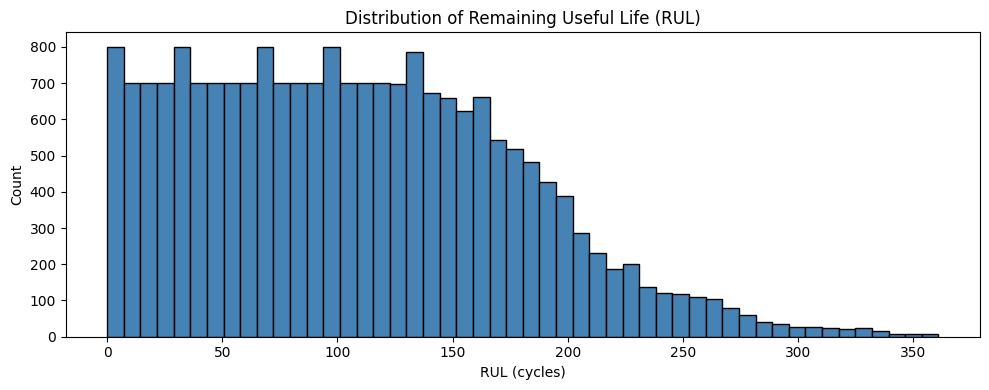

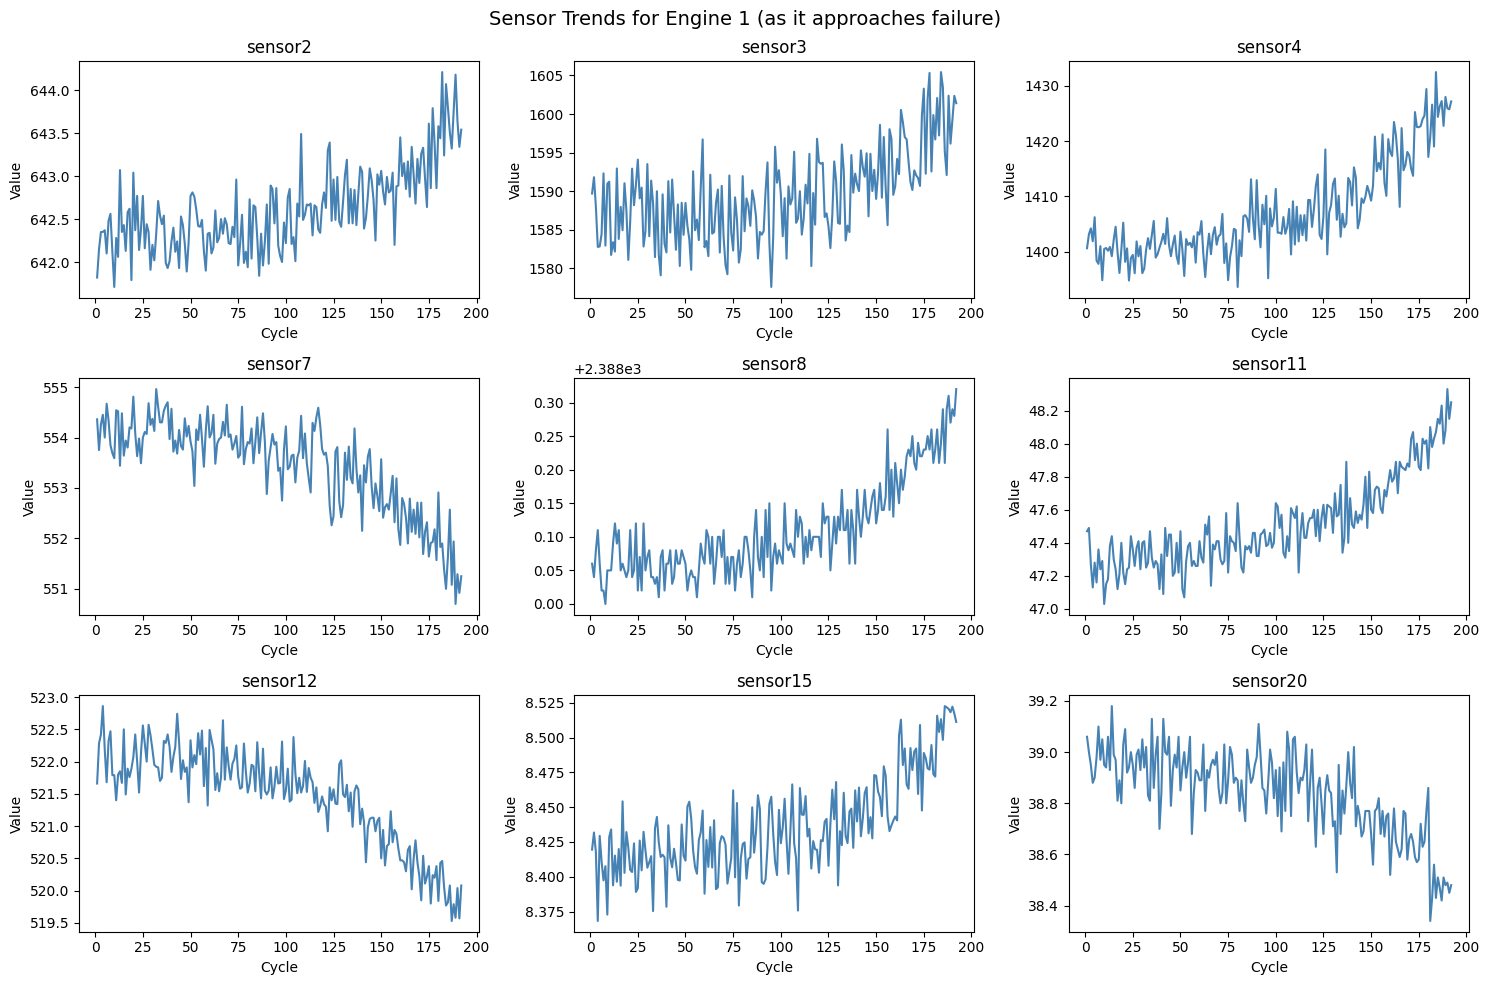

In [4]:
# Plot 1 — RUL Distribution
plt.figure(figsize=(10, 4))
plt.hist(train['RUL'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL (cycles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2 — Sensor trends for Engine 1 as it approaches failure
engine_1 = train[train['engine_id'] == 1].sort_values('cycle')

sensors_to_plot = ['sensor2', 'sensor3', 'sensor4', 'sensor7',
                   'sensor8', 'sensor11', 'sensor12', 'sensor15', 'sensor20']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Sensor Trends for Engine 1 (as it approaches failure)', fontsize=14)

for i, sensor in enumerate(sensors_to_plot):
    ax = axes[i//3][i%3]
    ax.plot(engine_1['cycle'], engine_1[sensor], color='steelblue')
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [5]:
# Check which sensors have near-zero variance (flat lines = useless)
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

sensor_std = train[sensor_cols].std()
print("Standard deviation per sensor:")
print(sensor_std.round(4))

# Drop sensors with std below threshold (flat sensors)
flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print(f"\nFlat sensors to drop: {flat_sensors}")

# Keep only useful sensors
useful_sensors = [s for s in sensor_cols if s not in flat_sensors]
print(f"Useful sensors: {useful_sensors}")

Standard deviation per sensor:
sensor1      0.0000
sensor2      0.5001
sensor3      6.1311
sensor4      9.0006
sensor5      0.0000
sensor6      0.0014
sensor7      0.8851
sensor8      0.0710
sensor9     22.0829
sensor10     0.0000
sensor11     0.2671
sensor12     0.7376
sensor13     0.0719
sensor14    19.0762
sensor15     0.0375
sensor16     0.0000
sensor17     1.5488
sensor18     0.0000
sensor19     0.0000
sensor20     0.1807
sensor21     0.1083
dtype: float64

Flat sensors to drop: ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
Useful sensors: ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


In [6]:
# Keep only useful sensors + metadata columns
keep_cols = ['engine_id', 'cycle', 'RUL'] + useful_sensors
train_clean = train[keep_cols].copy()

print("Clean dataset shape:", train_clean.shape)
print("\nColumns kept:", list(train_clean.columns))

# Check for missing values
print("\nMissing values:")
print(train_clean.isnull().sum().sum(), "total missing values")

# Basic stats on RUL
print("\nRUL Statistics:")
print(train_clean['RUL'].describe().round(2))

# Save clean data
train_clean.to_csv('../data/processed/train_clean.csv', index=False)
print("\nClean data saved to data/processed/train_clean.csv")

Clean dataset shape: (20631, 17)

Columns kept: ['engine_id', 'cycle', 'RUL', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']

Missing values:
0 total missing values

RUL Statistics:
count    20631.00
mean       107.81
std         68.88
min          0.00
25%         51.00
50%        103.00
75%        155.00
max        361.00
Name: RUL, dtype: float64

Clean data saved to data/processed/train_clean.csv
